In [ ]:
import numpy as np, pandas as pd
from abs_affinity_based_slotting.config import RAW_DIR
from abs_affinity_based_slotting.data import WarehouseDataLoader, split_picking_events
from abs_affinity_based_slotting.demand import build_cooccurrence, build_sku_demand, affinity_registry, filter_registry
from abs_affinity_based_slotting.warehouse import occupied_locations, build_location_costs, build_bay_distance_matrix
from abs_affinity_based_slotting.slotting import build_instance
from abs_affinity_based_slotting.clustering import clustering_registry
from abs_affinity_based_slotting.methods import (aggregate_clusters, assign_locations_to_clusters,
    BiLevelSlotting, LinearAssignmentSlotting)
from abs_affinity_based_slotting.evaluation import Evaluator

In [2]:
ds = WarehouseDataLoader(RAW_DIR).load_all()
split = split_picking_events(ds.picking_events, test_size=0.2)
universe = occupied_locations(ds.initial_stock)["sku"].to_numpy()
co = build_cooccurrence(split.train, skus=universe)
A = filter_registry.get("top_k")(k=10).filter(affinity_registry.get("jaccard")().build(co.matrix, co.support, co.n_batches))

instance = build_instance(build_sku_demand(split.train), 
                          build_location_costs(ds.initial_stock, ds.distances),
                          build_bay_distance_matrix(ds.distances), 
                          initial_stock=ds.initial_stock,
                          skus=universe, 
                          affinity=A)
evaluator = Evaluator.from_tables(ds.coordinates, ds.distances, ds.initial_stock)

In [3]:
#  posicion en el recorrido (snake) por ubicacion
# snake key por bay = pasillo*1000 + numero de bay (igual que el evaluador)
coord = ds.coordinates.set_index("bay_id")
bay_key = coord["aisle"].astype(float) * 1000.0 + coord["bay_number"].astype(float)
bay_key = bay_key.reindex(instance.bay_ids).to_numpy()
bay_key = np.nan_to_num(bay_key, nan=np.nanmax(bay_key) + 1.0)   # bays sin coord (dock) al final
snake_pos = bay_key[instance.location_bay]                        # por ubicacion (orden de location_ids)
print("snake_pos:", snake_pos.shape, "rango", snake_pos.min(), "-", snake_pos.max())

snake_pos: (30000,) rango 1001.0 - 25040.0


In [4]:

#  zonas del Problema 1: dock (bandas) vs snake (compacto)
labels = clustering_registry.get("merchant")().cluster(instance)
agg = aggregate_clusters(instance, labels)

zones_dock  = assign_locations_to_clusters(instance, agg)                          # costo = distancia al dock
zones_snake = assign_locations_to_clusters(instance, agg, location_cost=snake_pos) # costo = posicion en recorrido

def spread_snake(zones):
    # cuanto se desparrama cada zona a lo largo del recorrido (menor = mas compacta)
    return np.mean([snake_pos[z].max() - snake_pos[z].min() for z in zones if len(z) > 0])

print(f"spread medio en recorrido  dock : {spread_snake(zones_dock):.0f}")
print(f"spread medio en recorrido  snake: {spread_snake(zones_snake):.0f}")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2805866
Academic license 2805866 - for non-commercial use only - registered to sa___@mi.unc.edu.ar
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2805866
Academic license 2805866 - for non-commercial use only - registered to sa___@mi.unc.edu.ar
spread medio en recorrido  dock : 10402
spread medio en recorrido  snake: 2202


In [ ]:
# impacto en rutas (evaluacion en test)
def run(name, method):
    sol = method.solve(instance)
    m = evaluator.evaluate(sol, split.test)
    return {"metodo": name, "mean": round(m.mean_batch_distance), "p95": round(m.p95_batch_distance)}

clu = clustering_registry.get("merchant")()
rows = [
    run("bilevel[merchant] dock",  BiLevelSlotting(clu, LinearAssignmentSlotting())),
    run("bilevel[merchant] snake", BiLevelSlotting(clu, LinearAssignmentSlotting(), location_cost=snake_pos)),
]
pd.DataFrame(rows)

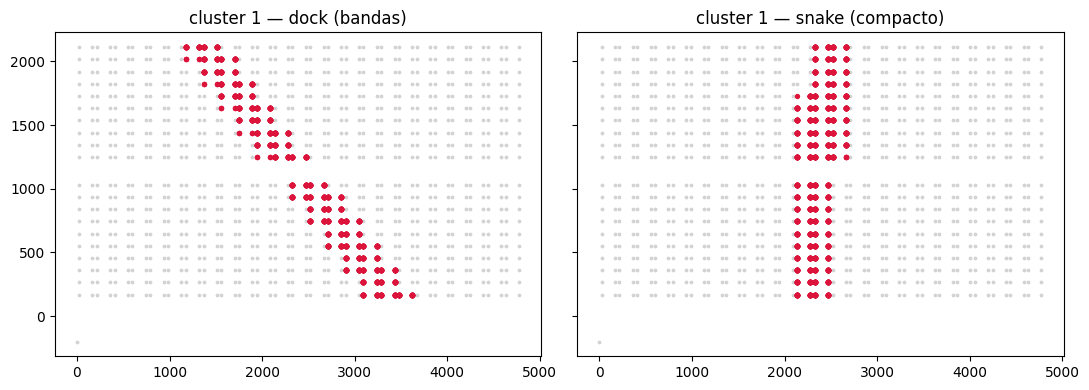

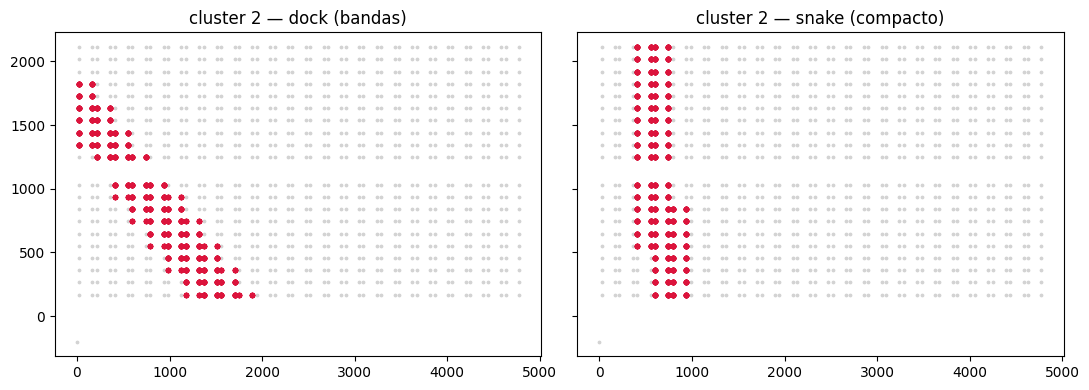

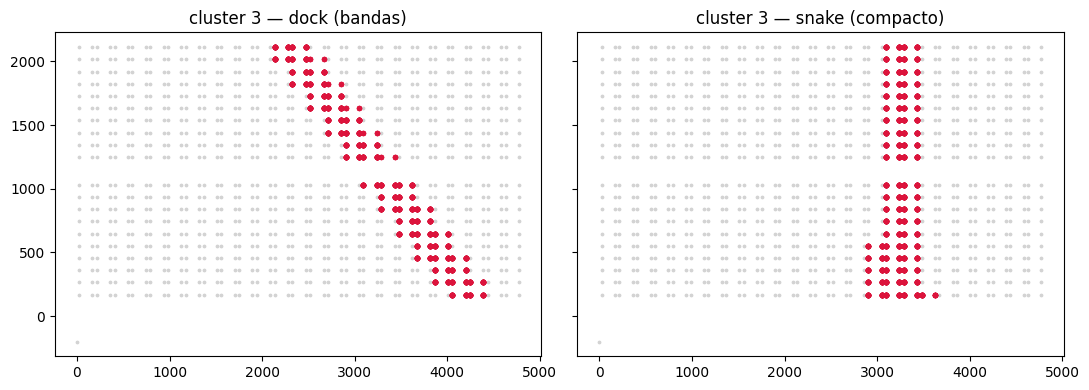

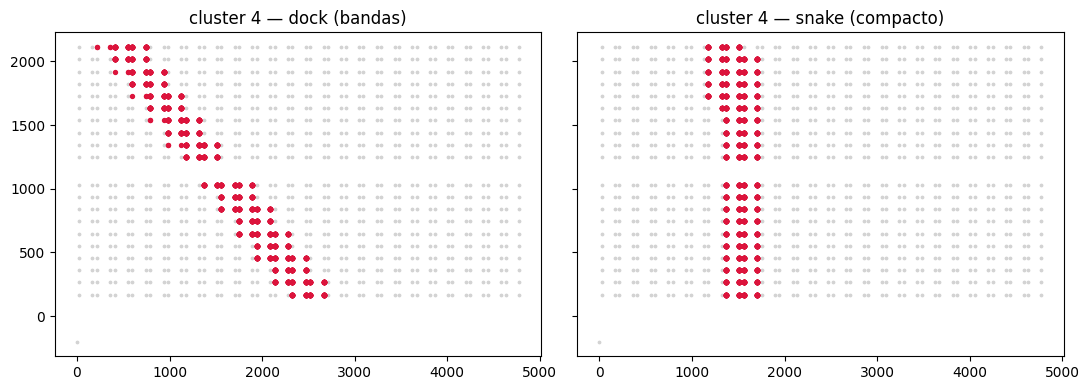

In [8]:

#  (opcional) — ver una zona en el plano: dock vs snake
import matplotlib.pyplot as plt
xy = ds.coordinates.set_index("bay_id")[["x","y"]].reindex(instance.bay_ids).to_numpy()
for c in range(1,5):
    #c = 3  # cluster a mirar
    fig, ax = plt.subplots(1, 2, figsize=(11,4), sharex=True, sharey=True)
    for a, zones, ttl in [(ax[0], zones_dock, "dock (bandas)"), (ax[1], zones_snake, "snake (compacto)")]:
        a.scatter(xy[:,0], xy[:,1], s=3, color="lightgray")
        bays_c = instance.location_bay[zones[c]]
        a.scatter(xy[bays_c,0], xy[bays_c,1], s=8, color="crimson")
        a.set_title(f"cluster {c} — {ttl}")
    plt.tight_layout()